In [34]:
import numpy as np
import matplotlib.pyplot as plt
import gwmemory as gwm
import utils_signal as us
import importlib
importlib.reload(us)

<module 'utils_signal' from '/home/stu_brabant/Memory_effect/FT_with_GWmemory/utils_signal.py'>

In [9]:
%pip install numpy
%pip install --no-build-isolation NRsur7dq2

Note: you may need to restart the kernel to use updated packages.
  Using cached NRSur7dq2-1.0.6.tar.gz (4.3 MB)
  Preparing metadata (pyproject.toml) ... done
  Created wheel for NRsur7dq2: filename=nrsur7dq2-1.0.6-cp311-cp311-linux_x86_64.whl size=4329672 sha256=3340690ad9222d6619662f71f53291319632965e15eff31ae5fee9fad7ebe9b0
  Stored in directory: /home/stu_brabant/.cache/pip/wheels/65/42/09/6c59a0cbd43678974f6ab1d3586eb901b10c8c11727d44f488
Successfully built NRsur7dq2
Note: you may need to restart the kernel to use updated packages.


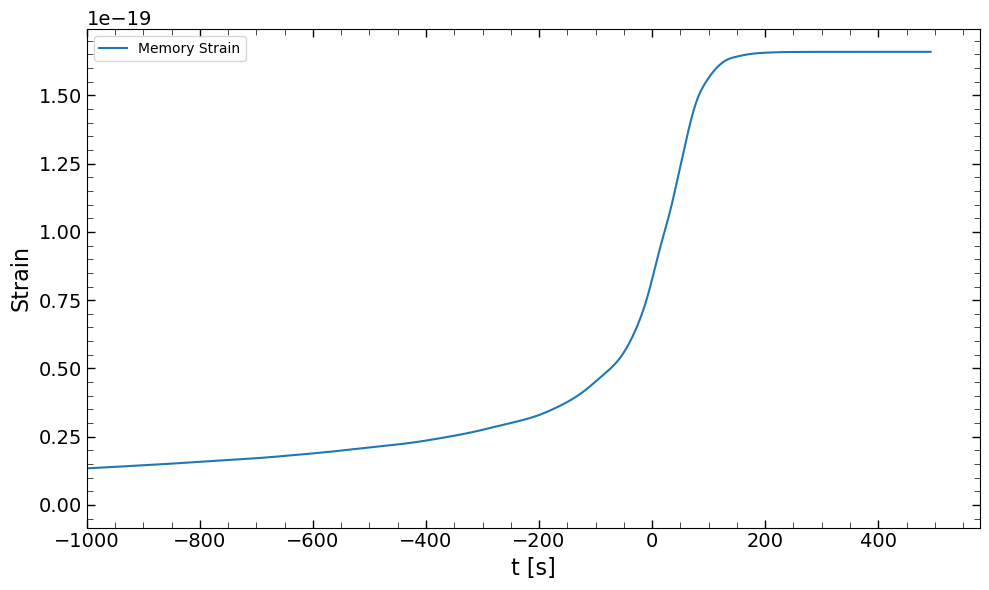

In [3]:
total_mass = 1e6
d = 6600 # distance in Mpc ~ z = 1
q = 1.0
inc = 1.047
spin_1 = [0, 0, 0]
spin_2 = [0, 0, 0]


parameters = dict(
    total_mass=total_mass,
    distance=d,
    q=q,
    inclination=inc,
    spin_1=spin_1,
    spin_2=spin_2,
    phase = 0, 
    inc=inc,
    model = 'NRSur7dq2'
)
h_mem, times_mem = gwm.time_domain_memory(**parameters)

plt.figure(figsize=(10, 6))

plt.plot(times_mem, h_mem['plus'], label='Memory Strain')
plt.xlabel('t [s]')
plt.xlim(-1000, 580)
plt.ylabel('Strain')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

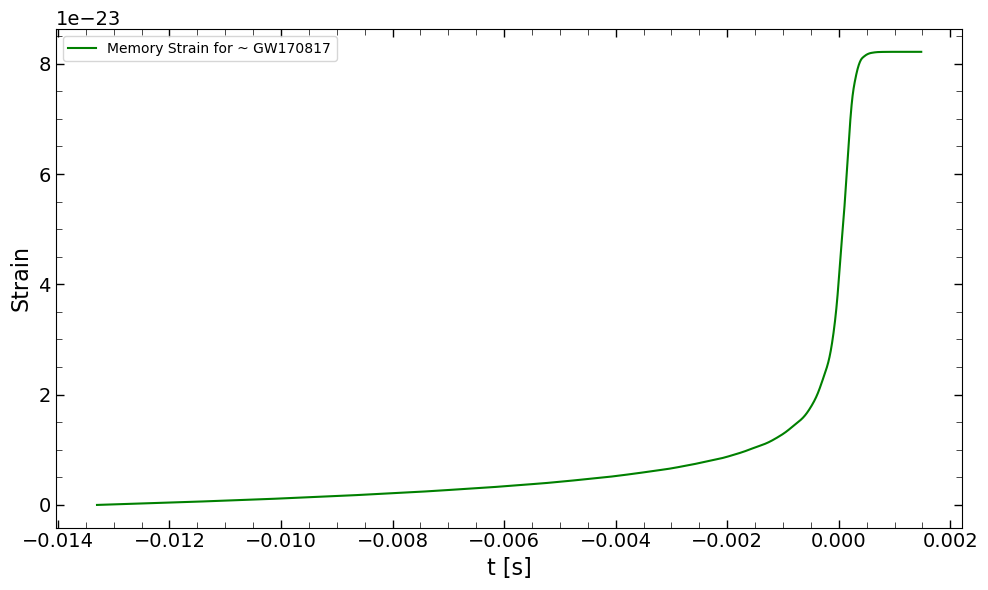

In [65]:
total_mass = 3
d = 40 # distance in Mpc ~ z = 1
q = 1.0
inc = 1.047
spin_1 = [0, 0, 0]
spin_2 = [0, 0, 0]


parameters = dict(
    total_mass=total_mass,
    distance=d,
    q=q,
    inclination=inc,
    spin_1=spin_1,
    spin_2=spin_2,
    phase = 0, 
    inc=inc,
    model = 'NRSur7dq2'
)
h_mem, times_mem = gwm.time_domain_memory(**parameters)

plt.figure(figsize=(10, 6))

plt.plot(times_mem, h_mem['plus'], label='Memory Strain for ~ GW170817', color='green')
plt.xlabel('t [s]')

plt.ylabel('Strain')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Take FT + padding + tapering

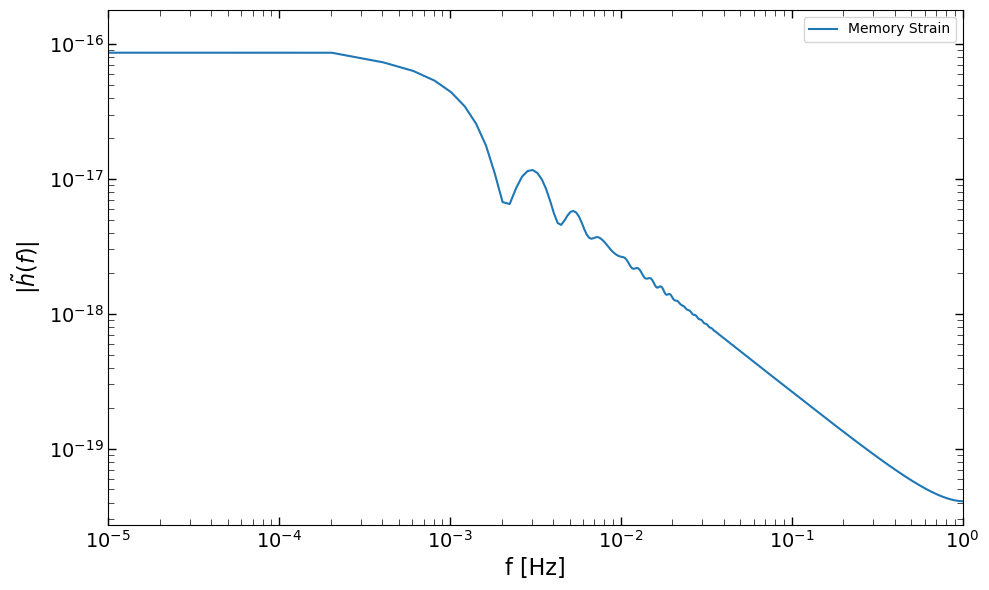

In [5]:
h_mem_init, frequencies_mem = gwm.frequency_domain_memory(**parameters)
plt.figure(figsize=(10, 6))
plt.loglog(frequencies_mem, np.abs(h_mem_init['plus']), label='Memory Strain')

plt.xlabel('f [Hz]')
plt.ylabel(r'$|\tilde{h}(f)|$')
plt.legend(loc='best')
plt.xlim(1e-5, 1e0)
plt.tight_layout()
plt.show()

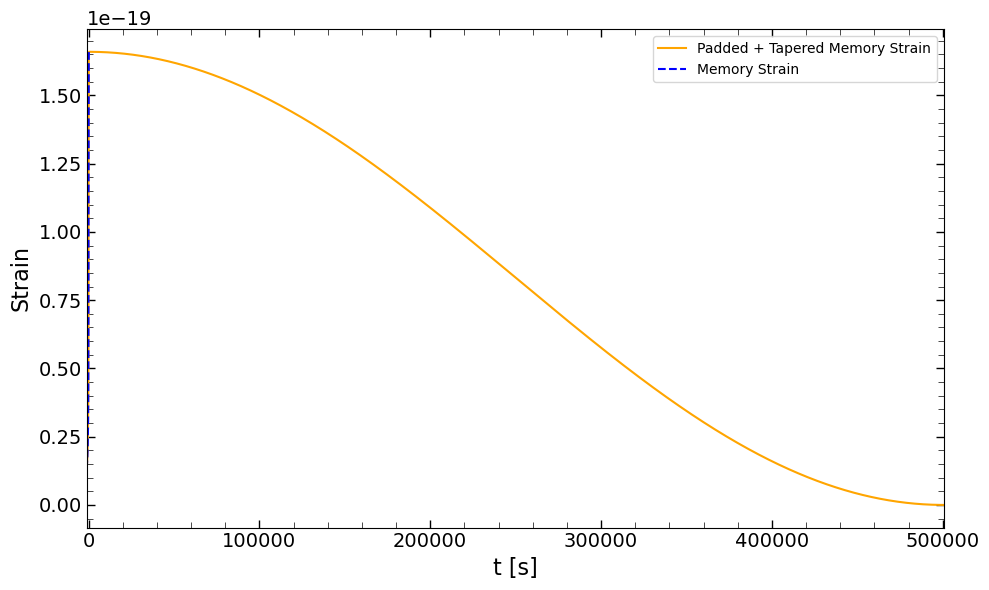

first non-zero frequency (original): 2.03e-04 Hz, FT: 1.98e-06 Hz
first non-zero frequency component (original): 8.61e-17, FT: 3.63e-14
FT of windowed + padded first 5 frequencies: [0.00000000e+00 1.98048875e-06 3.96097749e-06 5.94146624e-06
 7.92195498e-06]
FT of windowed + padded first 5 values: [ 8.44831814e-14+0.00000000e+00j -1.69969637e-15-3.62979950e-14j
 -1.47020888e-15-1.43815646e-14j -1.43448512e-15-9.17328062e-15j
 -1.41893751e-15-6.72608850e-15j]


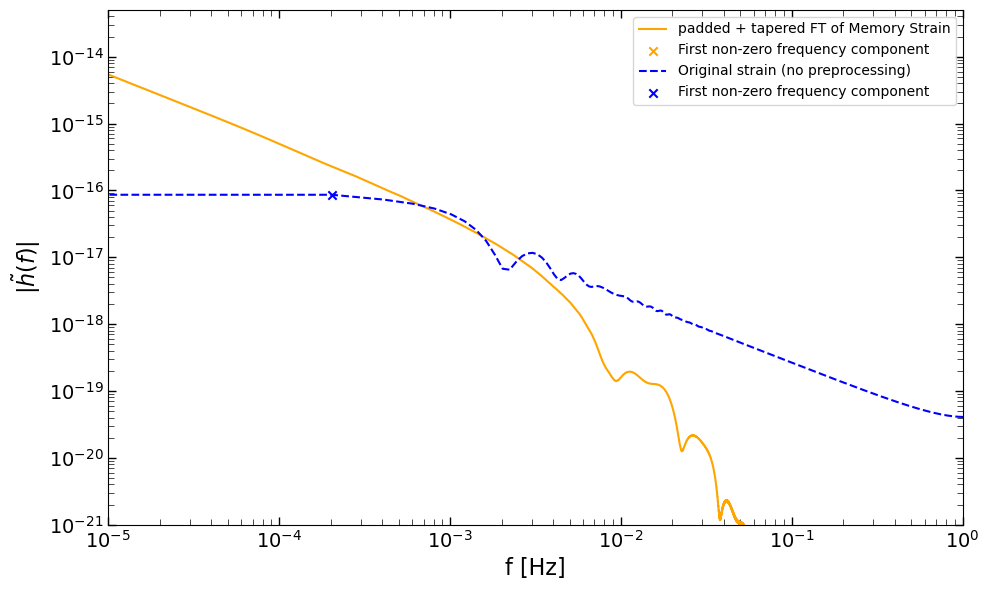

In [55]:
# try taking the FT of the time-domain memory and compute it with padding and tapering, to see if we can recover the same frequency-domain memory.
parameters = dict(
    total_mass=total_mass,
    distance=d,
    q=q,
    inclination=inc,
    spin_1=spin_1,
    spin_2=spin_2,
    phase = 0, 
    inc=inc,
    model = 'NRSur7dq2'
)
h_mem, times_mem = gwm.time_domain_memory(**parameters)
h_mem = h_mem['plus']

times_padded, h_mem_windowed = us.pad_and_taper(h_mem, times_mem, 500000, alpha = 1)

plt.figure(figsize=(10, 6))
plt.plot(times_padded, h_mem_windowed, label='Padded + Tapered Memory Strain', c = 'orange')
plt.plot(times_mem, h_mem, label='Memory Strain', c= 'blue', ls = '--')
plt.xlabel('t [s]')
plt.xlim(-1000, times_padded[-1]+10)
plt.ylabel('Strain')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Compute the FT with numpy's FFT
frequencies_ft = np.fft.rfftfreq(len(times_padded), d=times_padded[1] - times_padded[0])
h_mem_ft = np.fft.rfft(h_mem_windowed)


plt.figure(figsize=(10, 6))
plt.loglog(frequencies_ft, np.abs(h_mem_ft), label='padded + tapered FT of Memory Strain', c = 'orange')
plt.scatter(frequencies_ft[1], np.abs(h_mem_ft[1]), c='orange', label='First non-zero frequency component', marker='x')
plt.loglog(frequencies_mem, np.abs(h_mem_init['plus']), label='Original strain (no preprocessing)', c= 'blue', ls = '--')
plt.scatter(frequencies_mem[1], np.abs(h_mem_init['plus'][1]), c='blue', label='First non-zero frequency component', marker='x')
print(f'first non-zero frequency (original): {frequencies_mem[1]:.2e} Hz, FT: {frequencies_ft[1]:.2e} Hz')
print(f'first non-zero frequency component (original): {np.abs(h_mem_init["plus"][1]):.2e}, FT: {np.abs(h_mem_ft[1]):.2e}')

print(f"FT of windowed + padded first 5 frequencies: {frequencies_ft[:5]}")
print(f"FT of windowed + padded first 5 values: {h_mem_ft[:5]}")
plt.xlabel('f [Hz]')
plt.ylabel(r'$|\tilde{h}(f)|$')
plt.legend(loc='best')
plt.xlim(1e-5, 1e0)
plt.ylim(1e-21, 5e-14)
plt.tight_layout()
plt.show()